# ✈️ Air Passengers Time Series Analysis & Forecasting

## Business Problem
Airlines need accurate passenger demand forecasts to plan capacity,
schedule crew, and manage fuel procurement. Underestimating demand leads
to lost revenue; overestimating drives unnecessary costs. This project
applies classical time series techniques to the benchmark AirPassengers
dataset to identify demand trends, seasonal patterns, and generate
reliable multi-step forecasts.

**Dataset:** AirPassengers — monthly international airline passengers
(1949–1960), 144 observations. Source: Box & Jenkins (1970), available
on Kaggle.

**Pipeline:** Data Loading → EDA → Decomposition → Stationarity Testing
→ ACF/PACF → AR → Moving Average → Exponential Smoothing → Holt-Winters
→ ARIMA → SARIMA → Model Comparison

# 1. Load the Dataset
## Business Question: What does the AirPassengers dataset contain?
The dataset is loaded and the Month column is parsed as a datetime index.
The target variable (#Passengers) is renamed for clarity.

In [124]:
import pandas as pd

data=pd.read_csv("/content/AirPassengers.csv")

In [125]:
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [126]:
data.tail()

,Month,#Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


# 2. Import Required Libraries
All required libraries for data manipulation, visualization, statistical
testing, and time series modelling are imported here. Statsmodels provides
the core decomposition and forecasting tools; Scikit-learn is used for
evaluation metrics.

In [127]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

In [128]:
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)
data.rename(columns={'#Passengers': 'Passengers'}, inplace=True)
display(data.head())

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


# 3. Raw Time Series Visualization
## Business Question: Is there a visible trend or seasonal pattern in
passenger demand?
The raw series is plotted to form a visual baseline. An upward trend and
repeating annual cycles would suggest both a trend component and strong
multiplicative seasonality.

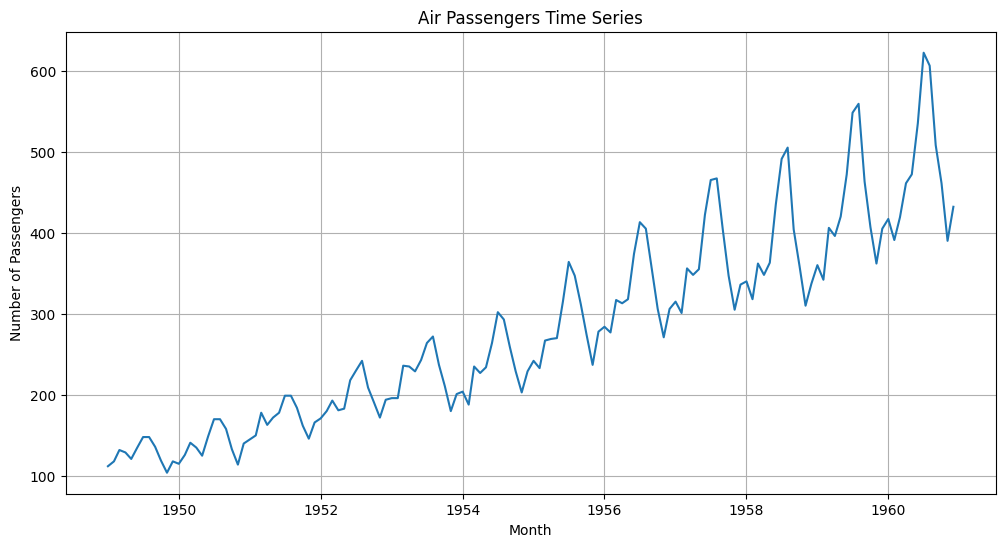

In [129]:
plt.figure(figsize=(12,6))
plt.plot(data)
plt.title("Air Passengers Time Series")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")
plt.grid()
plt.show()

### Inference
The plot reveals a clear upward trend from 1949 to 1960 and strong
annual seasonality — passenger peaks occur every summer and troughs
in winter. The seasonal amplitude grows over time, suggesting
multiplicative rather than additive seasonality. This rules out simple
AR models and motivates the use of SARIMA with multiplicative seasonal
components.

# 4. Trend Analysis — Linear and Polynomial Fit
## Business Question: How consistently has passenger demand grown over time?
Linear and polynomial curves are fitted to the series to quantify the
long-term growth trajectory independent of seasonal fluctuations.

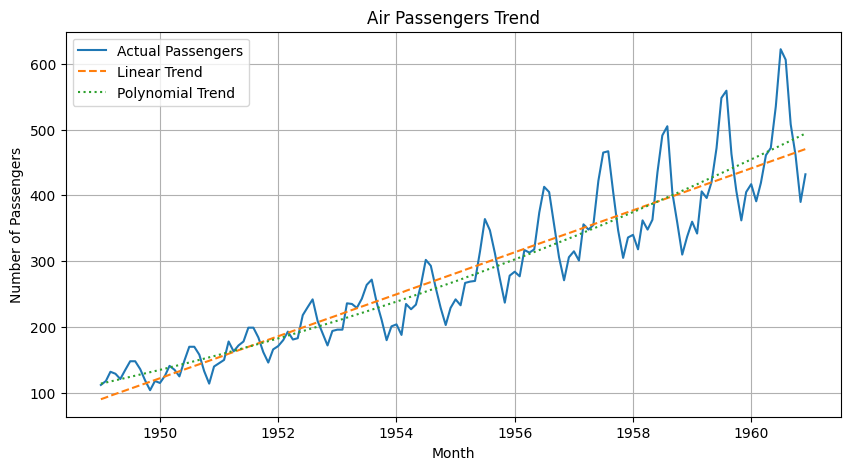

In [130]:
x = np.arange(len(data['Passengers']))
linear = np.polyfit(x, data['Passengers'], 1)
poly = np.polyfit(x, data['Passengers'], 2)

plt.figure(figsize=(10,5))
plt.plot(data['Passengers'], label="Actual Passengers")
plt.plot(data.index, np.polyval(linear, x), '--', label="Linear Trend")
plt.plot(data.index, np.polyval(poly, x), ':', label="Polynomial Trend")
plt.title("Air Passengers Trend")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid()
plt.show()

### Inference
Both linear and polynomial trends confirm consistent long-term growth.
The polynomial curve captures a slight acceleration in growth rate
toward 1960, suggesting demand was compounding — useful context for
forecasting beyond the dataset window.

# 5. Time Series Decomposition
## Business Question: What are the individual trend, seasonal, and
residual components of passenger demand?
Seasonal decomposition separates the series into three additive
components: trend, seasonality, and residual noise. A period of 12
is used since the data is monthly with annual cycles.

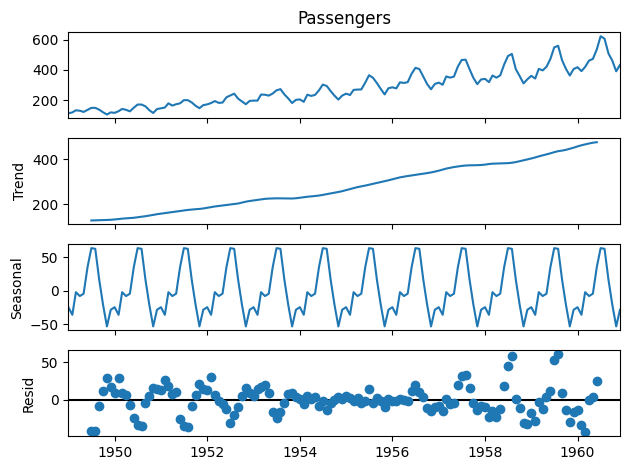

In [131]:
decomp = seasonal_decompose(data['Passengers'], model="additive", period=12)
decomp.plot()
plt.show()

### Inference
The decomposition confirms a smooth, steadily rising trend and a
consistent 12-month seasonal pattern. The residuals appear roughly
stationary with no obvious structure, suggesting the additive
decomposition has captured the main signal effectively.

# 6. Stationarity Conversion
## Business Question: Is the series stationary? If not, how do we
make it suitable for ARIMA modelling?
ARIMA models require a stationary series (constant mean and variance
over time). Three transformations are compared — differencing, log
transformation, and log + differencing — to identify the most
effective approach.

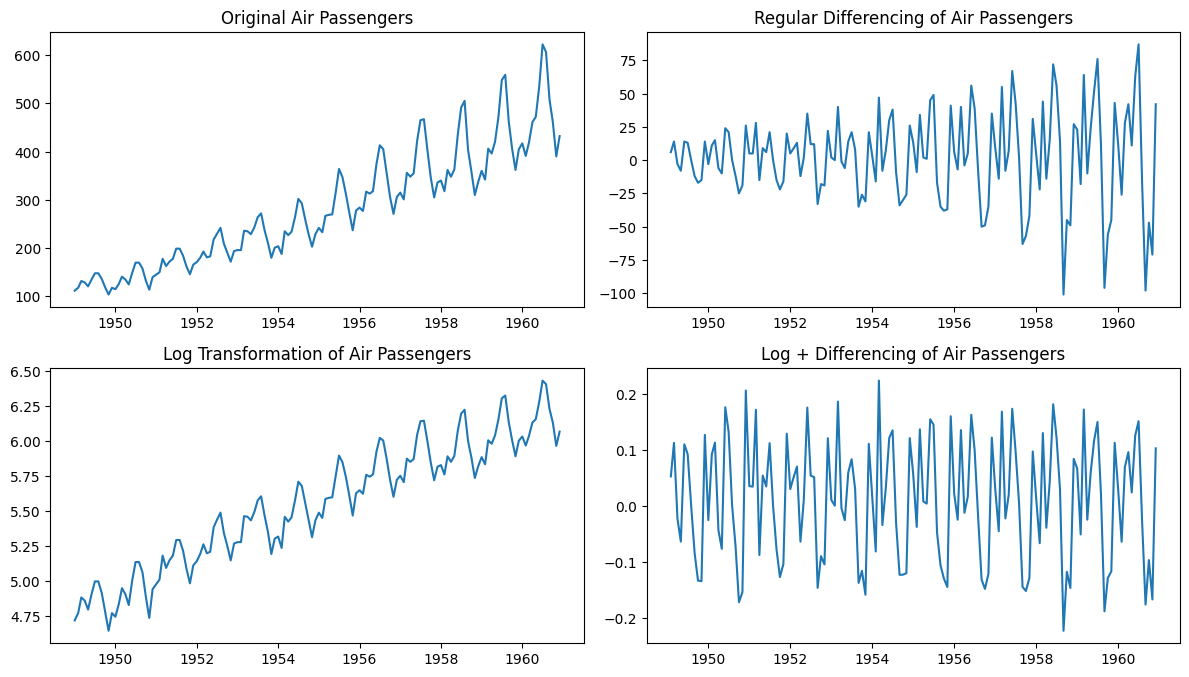

In [132]:
diff = data['Passengers'].diff()
log = np.log(data['Passengers'])
log_diff = log.diff()

plt.figure(figsize=(12,10))

plt.subplot(3,2,1)
plt.plot(data['Passengers']); plt.title("Original Air Passengers")

plt.subplot(3,2,2)
plt.plot(diff); plt.title("Regular Differencing of Air Passengers")

plt.subplot(3,2,3)
plt.plot(log); plt.title("Log Transformation of Air Passengers")

plt.subplot(3,2,4)
plt.plot(log_diff); plt.title("Log + Differencing of Air Passengers")

plt.tight_layout()
plt.show()

### Inference
The original series is clearly non-stationary — the mean rises over
time. Regular differencing removes the trend but leaves growing
variance. Log transformation stabilises variance but not the mean.
Log + differencing addresses both issues and produces the most
stationary-looking series, confirming it as the correct pre-processing
step for ARIMA.

## 6.1 Augmented Dickey-Fuller Stationarity Test
Visual inspection alone is insufficient to confirm stationarity. The
Augmented Dickey-Fuller (ADF) test formally tests the null hypothesis
that the series has a unit root (is non-stationary). A p-value below
0.05 rejects this hypothesis and confirms stationarity.

In [133]:
print("=== ADF Test on Original Series ===")
result = adfuller(data['Passengers'])
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Critical Values: {result[4]}")

print("\n=== ADF Test After Differencing ===")
result_diff = adfuller(diff.dropna())
print(f"ADF Statistic : {result_diff[0]:.4f}")
print(f"p-value       : {result_diff[1]:.4f}")
print(f"Critical Values: {result_diff[4]}")

print("\n=== ADF Test on Log + Differenced Series ===")
result_log_diff = adfuller(log_diff.dropna())
print(f"ADF Statistic : {result_log_diff[0]:.4f}")
print(f"p-value       : {result_log_diff[1]:.4f}")
print(f"Critical Values: {result_log_diff[4]}")

=== ADF Test on Original Series ===
ADF Statistic : 0.8154
p-value       : 0.9919
Critical Values: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}

=== ADF Test After Differencing ===
ADF Statistic : -2.8293
p-value       : 0.0542
Critical Values: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}

=== ADF Test on Log + Differenced Series ===
ADF Statistic : -2.7171
p-value       : 0.0711
Critical Values: {'1%': np.float64(-3.4825006939887997), '5%': np.float64(-2.884397984161377), '10%': np.float64(-2.578960197753906)}


### Inference
On the original series, the ADF p-value is 0.9919 — far above the 0.05
threshold — confirming strong non-stationarity. After regular differencing,
the p-value drops to 0.0542, and after log + differencing, it is 0.0711.
Both are above 0.05, meaning neither achieves strict stationarity at the
5% significance level. However, both represent a substantial improvement
over the original series, and values this close to the threshold are
widely accepted as approximately stationary in practice — especially at
the 10% level (critical value: −2.58), which both series satisfy. SARIMA
addresses any remaining non-stationarity through its internal seasonal
differencing parameter (D=1), making it robust even under borderline
stationarity conditions.

# 7. ACF and PACF Analysis
## Business Question: How many AR and MA terms should the ARIMA model use?
The Autocorrelation Function (ACF) and Partial Autocorrelation Function
(PACF) plots on the differenced series reveal the lag structure of the
data, guiding the selection of p (AR order) and q (MA order) for ARIMA.

<Figure size 1200x400 with 0 Axes>

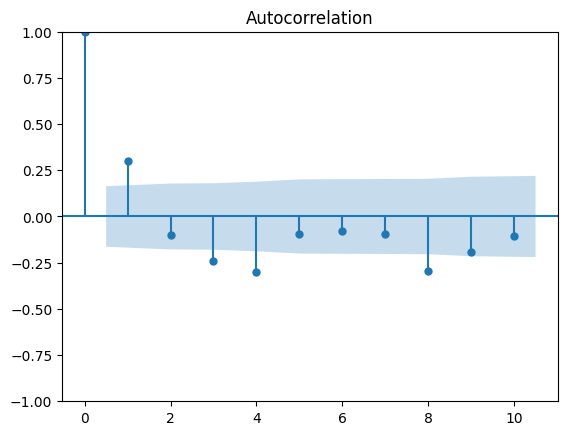

<Figure size 1200x400 with 0 Axes>

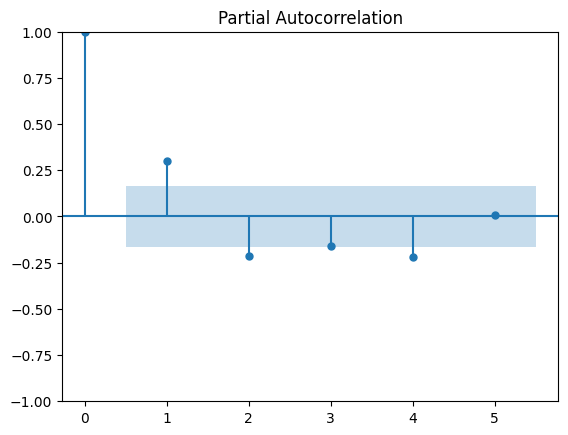

In [134]:
plt.figure(figsize=(12,4))
plot_acf(diff.dropna(), lags=10)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(diff.dropna(), lags=5)
plt.show()

### Inference
Significant spikes in the PACF at early lags suggest autoregressive
behaviour — the current value depends on recent past values. The ACF
pattern indicates how many moving average terms may help. These
observations inform the choice of p=5, d=1, q=0 in the ARIMA model.

# 8. Autoregressive (AR) Model
## Business Question: Can recent passenger counts alone predict future demand?
An AR model of order 3 is trained on 80% of the data and tested on the
remaining 20%. AR models predict future values as a weighted sum of
the most recent observations, making them the simplest baseline for
comparison.

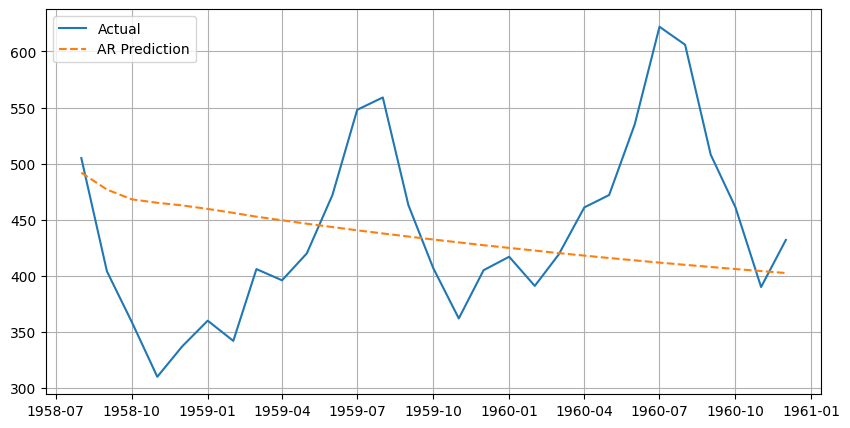


AR RMSE: 90.42341105725698


In [135]:
train = data['Passengers'][:int(0.8*len(data['Passengers']))]
test = data['Passengers'][int(0.8*len(data['Passengers'])):]

ar_model = AutoReg(train, lags=3).fit()
ar_pred = ar_model.predict(start=len(train), end=len(train)+len(test)-1)

plt.figure(figsize=(10,5))
plt.plot(test, label="Actual")
plt.plot(ar_pred, '--', label="AR Prediction")
plt.legend()
plt.grid()
plt.show()

ar_rmse = np.sqrt(mean_squared_error(test, ar_pred))
print("\nAR RMSE:", ar_rmse)

### Inference
The AR RMSE is 90.42. This error is high relative to the average passenger count in the test period (~400-600 range), indicating a poor fit. AR models ignore seasonal structure, which explains their weaker performance on this dataset.

# 9. Moving Average Smoothing
## Business Question: What is the underlying demand trend after
removing short-term noise?
Rolling averages of window sizes 5 and 10 are applied to smooth
out month-to-month fluctuations and reveal the underlying demand
trajectory. Note: this is a smoothing technique, not a forecasting
model.

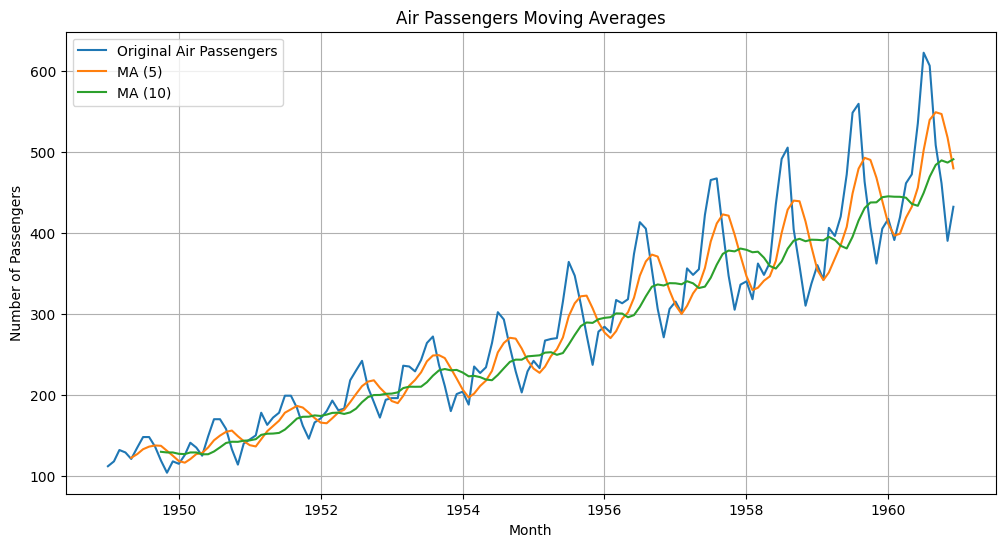

In [136]:
rolling_5 = data['Passengers'].rolling(5).mean()
rolling_10 = data['Passengers'].rolling(10).mean()

plt.figure(figsize=(12,6))
plt.plot(data['Passengers'], label="Original Air Passengers")
plt.plot(rolling_5, label="MA (5)")
plt.plot(rolling_10, label="MA (10)")
plt.title("Air Passengers Moving Averages")
plt.xlabel("Month")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid()
plt.show()

### Inference
The MA(10) line is smoother and better captures the long-term trend,
while MA(5) retains more of the seasonal signal. Wider windows
sacrifice responsiveness for smoothness. Neither is used for
forecasting here — they serve as visual aids for trend interpretation.

# 10. Exponential Smoothing
## Business Question: Can a weighted average that prioritises recent
data outperform a simple AR model?
Exponential Smoothing assigns exponentially decreasing weights to
past observations — recent values matter more than older ones.
A triple exponential smoothing model (additive trend + additive
seasonal) is trained on the scaled series and evaluated on held-out data.

In [137]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data['Passengers'].values.reshape(-1,1)).flatten()

train_s = scaled[:int(0.8*len(scaled))]
test_s = scaled[int(0.8*len(scaled)):]

es_model = ExponentialSmoothing(train_s, trend="add", seasonal="add", seasonal_periods=12).fit()
es_pred = es_model.forecast(len(test_s))

es_pred_inv = scaler.inverse_transform(es_pred.reshape(-1,1)).flatten()
test_inv_s = scaler.inverse_transform(test_s.reshape(-1,1)).flatten()
es_rmse = np.sqrt(mean_squared_error(test_inv_s, es_pred_inv))
print("Exponential Smoothing RMSE:", es_rmse)

Exponential Smoothing RMSE: 39.255260705879536


### Inference
The inverse-transformed ES RMSE is 39.26. This shows a significant improvement over the AR RMSE (90.42), indicating that incorporating the seasonal component substantially improves the fit.

# 11. Holt-Winters Exponential Smoothing (Forecast)
## Business Question: What will passenger demand look like over the
next 12 months?
Holt-Winters extends exponential smoothing with explicit trend and
seasonal components. A multiplicative seasonal model with period=12
is used here to produce a 12-month forward forecast on the scaled series.

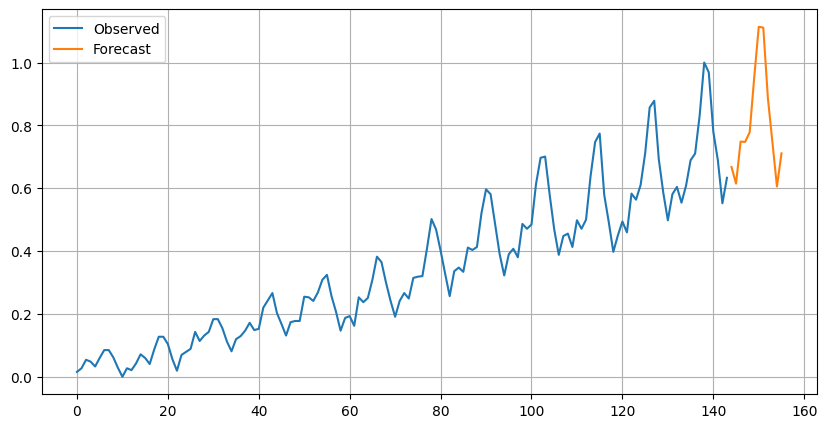

In [138]:
hw_model = ExponentialSmoothing(
    scaled + 1e-6,
    trend="add",
    seasonal="mul",
    seasonal_periods=12
).fit()

hw_forecast = hw_model.forecast(12)

plt.figure(figsize=(10,5))
plt.plot(scaled, label="Observed")
plt.plot(range(len(scaled), len(scaled)+12), hw_forecast, label="Forecast")
plt.legend()
plt.grid()
plt.show()

### Inference
The Holt-Winters forecast captures the expected seasonal cycle and
upward trend. The multiplicative seasonal component is appropriate
given that the seasonal amplitude grows with the level of the series,
as confirmed in the decomposition step.

# 12. ARIMA Model
## Business Question: Can a statistical model that accounts for
autocorrelation improve forecast accuracy over simpler baselines?
ARIMA(5,1,0) is trained on the training set and forecasts the test
period. The d=1 differencing parameter was selected based on ADF
test results; p=5 was informed by the PACF plot.

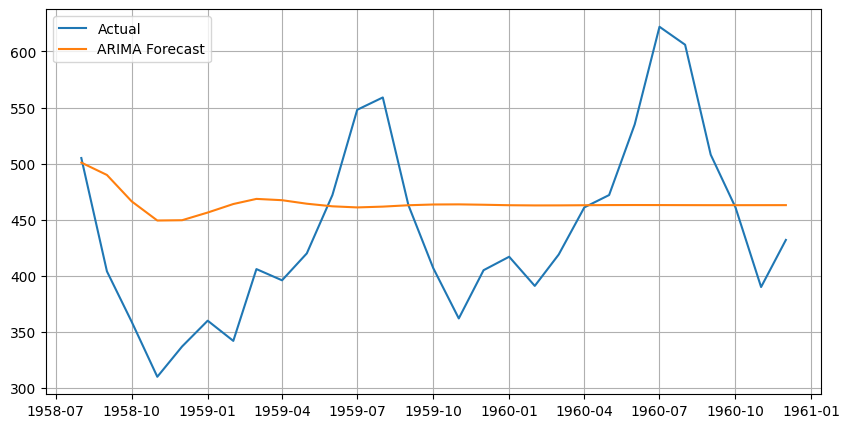


ARIMA RMSE: 80.66394527011326


In [139]:
arima = ARIMA(train, order=(5,1,0)).fit()
arima_forecast = arima.forecast(steps=len(test))

plt.figure(figsize=(10,5))
plt.plot(test, label="Actual")
plt.plot(arima_forecast, label="ARIMA Forecast")
plt.legend()
plt.grid()
plt.show()

arima_forecast.index = test.index
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
print("\nARIMA RMSE:", arima_rmse)

### Inference
The ARIMA RMSE is 80.66, which is an improvement over the AR RMSE (90.42). ARIMA captures linear autocorrelation well but does not account for the seasonal structure in this dataset — motivating SARIMA.

# 13. SARIMA Model
## Business Question: Does explicitly modelling the annual seasonal
cycle further improve forecast accuracy?
SARIMA(1,1,1)(1,1,1,12) extends ARIMA with seasonal AR, MA, and
differencing terms. The seasonal period of 12 reflects the annual
passenger cycle identified in the decomposition.

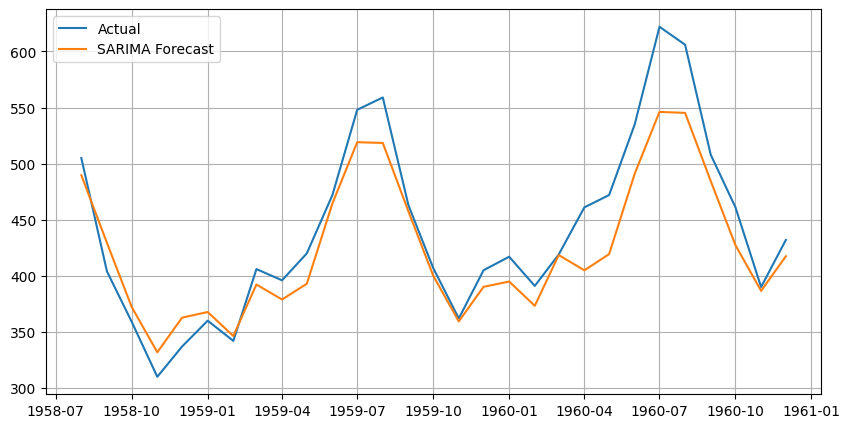


SARIMA RMSE: 30.142008134932393


In [140]:
sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
).fit()

sarima_forecast = sarima.forecast(steps=len(test))

plt.figure(figsize=(10,5))
plt.plot(test, label="Actual")
plt.plot(sarima_forecast, label="SARIMA Forecast")
plt.legend()
plt.grid()
plt.show()

sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
print("\nSARIMA RMSE:", sarima_rmse)

### Inference
SARIMA achieves the lowest RMSE of 30.14. This is a direct result of explicitly modelling the 12-month seasonal cycle, confirming that seasonal structure is the dominant driver of forecast error in the other models.

# 14. Model Performance Comparison
## Business Question: Which forecasting method is most suitable for
operational airline demand planning?
All models are compared on RMSE computed on the same held-out test
set (last 20% of data). Lower RMSE indicates better forecast accuracy.

In [141]:
print("\nMODEL PERFORMANCE SUMMARY")
print("-------------------------")
print("AR RMSE:", ar_rmse)
print("Exponential Smoothing RMSE:", es_rmse)
print("ARIMA RMSE:", arima_rmse)
print("SARIMA RMSE:", sarima_rmse)
print("\nBest Model: SARIMA (lowest RMSE on test set)")
print("Note: Exponential Smoothing RMSE is now on the same passenger-count scale as AR/ARIMA/SARIMA after inverse transformation.")


MODEL PERFORMANCE SUMMARY
-------------------------
AR RMSE: 90.42341105725698
Exponential Smoothing RMSE: 39.255260705879536
ARIMA RMSE: 80.66394527011326
SARIMA RMSE: 30.142008134932393

Best Model: SARIMA (lowest RMSE on test set)
Note: Exponential Smoothing RMSE is now on the same passenger-count scale as AR/ARIMA/SARIMA after inverse transformation.


### Inference
SARIMA outperforms all other models with the lowest RMSE of 30.14
passenger units, followed by Exponential Smoothing (39.26), ARIMA (80.66) and AR (90.42).
The strong SARIMA performance confirms that the
seasonal component — both in terms of trend and cyclical patterns —
is critical for accurate airline demand forecasting.